# Homework 2

In [3]:
# we need it in all codes
import numpy as np 
import math
import matplotlib.pyplot as plt

from PIL import Image
# see functions here
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/routines.array-manipulation.html
#

# basic vector and matrix operations
# general principle: we do not have to write functions for everything
# moreover, built-in vectorized operations are rather fast




(a) Read the RGB code of a picture and apply left-right mirroring

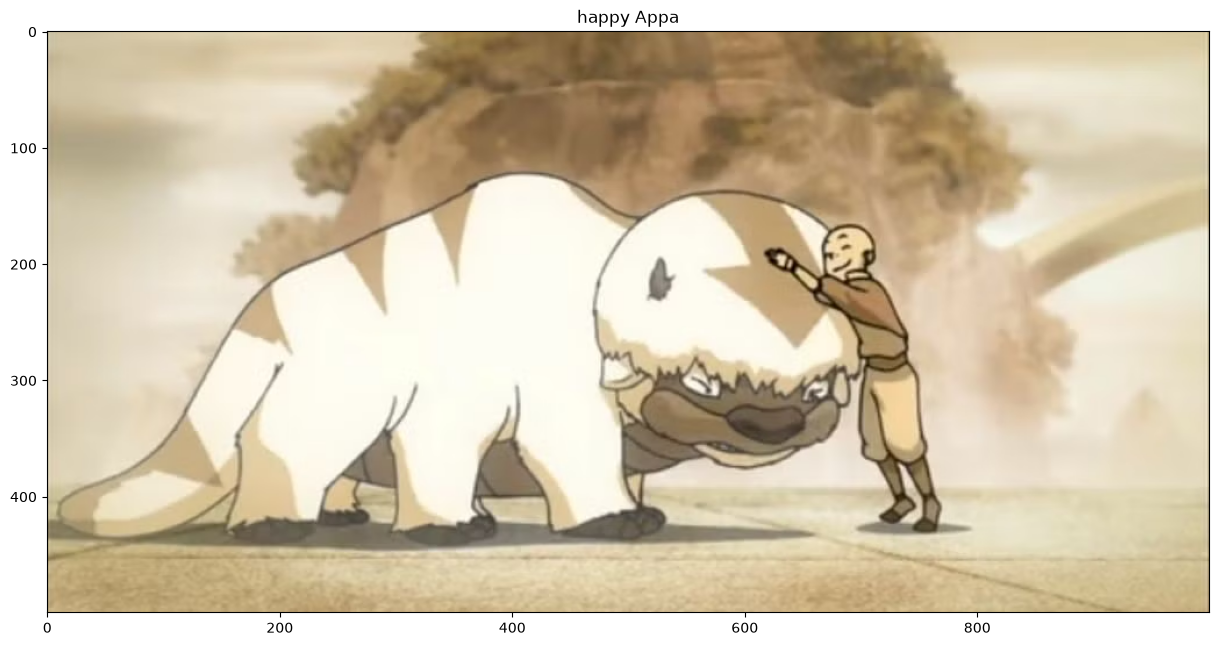

In [4]:
#First, let's turn our picture into an array:
image = np.array(Image.open("appa.jpg"))

# Let's see how this picture looks like
fig = plt.figure(figsize=(15, 10))
imgplot = plt.imshow(image)
plt.title("happy Appa")
plt.show()

In [5]:
#Recall this is a multidimensional array:
print(np.shape(image))
print(f"This means in the variable image there are 3 matrices with {np.shape(image)[0]} and {np.shape(image)[1]} columns. ")
#First matrix stores red colors of each pixel
red_tones = image[:,:,0]
#Second matrix stores green colors of each pixel
green_tones = image[:,:,1]
#Third matrix stores blue colors of each pixel
blue_tones = image[:,:,0]

(500, 1000, 3)
This means in the variable image there are 3 matrices with 500 and 1000 columns. 


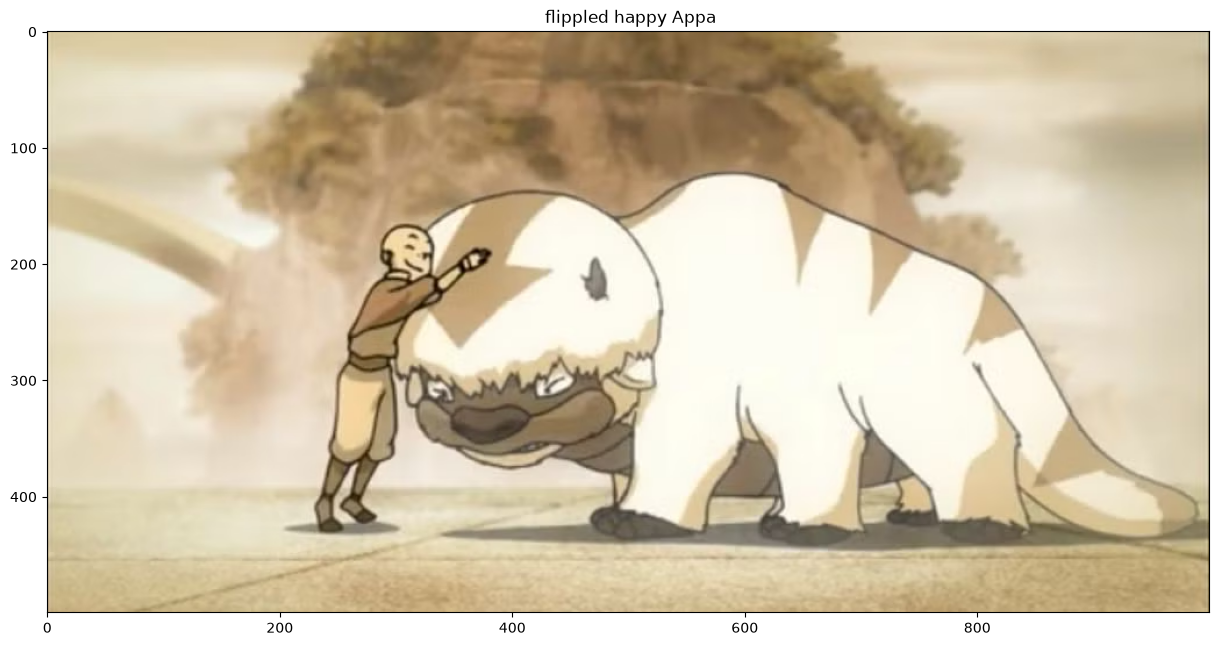

In [6]:
#Left-right mirroring would be equivalent to flipping each row
#axis = 0 flips rows: e.g row_1, row_2, row_3 => row_3, row_2, row_1
#axis = 1 flips columns
image_flipped = np.flip(image,axis =1)

# Let's see how this picture looks like
fig = plt.figure(figsize=(15, 10))
imgplot = plt.imshow(image_flipped)
plt.title(" flippled happy Appa")
plt.show()


(b) Take the numbers 1,2,. . . , 12. Partition them into 2 groups such that each group has six
elements. Print all different partitions in a matrix, where one row shows one partition

In [7]:
#First, we count how many ways we can do this partitions: out of the 12 numbers there are six ways I can choose these numbers (order does not matter) to make the first group. This is:
#(12 6) ways of making one group (the other group will just complete itself after we choose). However, the order between these two groups does not mater, so we divide this number by 2:
#                                                                   1/2 (12 6) = 462


# We can see that every partition can be represented by an integer number, and the partition is given by the 12 digit binary representation of this number.
#With 12 digit, there are 2^12 possibilities
integers = np.arange (2 ** 12)

#How can we transform each of these integers in their binary form? Each integer binary representation will be a row of a matrix called binary:
binary = np.zeros((np.size(integers), 12), dtype=bool) # start with a matrix of zeros, then change to one the bits accordingly.

for j in np.arange(12):
    binary_digits_j = (integers % 2)  
    binary[:,-(j+1)] = binary_digits_j #j starts at 0
    integers = integers // 2


#We will only use the binary digits that have 6 1's, and use them to place the corresponding numbers in the first group 
#Then let's find the rows where this happens, the indexes of this rows will be given by valid_binary:
##we also use the rule that 1 is always in group 1 so &binary[:,0] ensures to take only rows whose first element is "TRUE" 
valid_binary = ( binary.sum(axis=1) == 6)  & binary[:,0] 
#updating my binary list:
binary = binary [valid_binary]

In [8]:
#Now that we have our integers encoded in binary form, we can form our partitions. The first 6 entries of each row is one group and the remainder the other group.
partition =np.empty((462, 12), dtype=int)
numbers = np.arange(1,13) #number that will be partitioned
for i in range(462):
    partition[i,0:6] = numbers[binary[i,:]] #ALWAYS REMEBER START:STOP PYTHON EXCLUDES THE STOP BUT INCLUDES START
    partition[i,6:12] = numbers[~binary[i,:]]

#printing partitions:
for i in range(462):
    print(f'Group 1: {partition[i, 0:6]} || Group 2: {partition[i, 6:12]}')

Group 1: [ 1  8  9 10 11 12] || Group 2: [2 3 4 5 6 7]
Group 1: [ 1  7  9 10 11 12] || Group 2: [2 3 4 5 6 8]
Group 1: [ 1  7  8 10 11 12] || Group 2: [2 3 4 5 6 9]
Group 1: [ 1  7  8  9 11 12] || Group 2: [ 2  3  4  5  6 10]
Group 1: [ 1  7  8  9 10 12] || Group 2: [ 2  3  4  5  6 11]
Group 1: [ 1  7  8  9 10 11] || Group 2: [ 2  3  4  5  6 12]
Group 1: [ 1  6  9 10 11 12] || Group 2: [2 3 4 5 7 8]
Group 1: [ 1  6  8 10 11 12] || Group 2: [2 3 4 5 7 9]
Group 1: [ 1  6  8  9 11 12] || Group 2: [ 2  3  4  5  7 10]
Group 1: [ 1  6  8  9 10 12] || Group 2: [ 2  3  4  5  7 11]
Group 1: [ 1  6  8  9 10 11] || Group 2: [ 2  3  4  5  7 12]
Group 1: [ 1  6  7 10 11 12] || Group 2: [2 3 4 5 8 9]
Group 1: [ 1  6  7  9 11 12] || Group 2: [ 2  3  4  5  8 10]
Group 1: [ 1  6  7  9 10 12] || Group 2: [ 2  3  4  5  8 11]
Group 1: [ 1  6  7  9 10 11] || Group 2: [ 2  3  4  5  8 12]
Group 1: [ 1  6  7  8 11 12] || Group 2: [ 2  3  4  5  9 10]
Group 1: [ 1  6  7  8 10 12] || Group 2: [ 2  3  4  5  9 11]

(c) Take a random array of size 6×6×6. Sort their layers such that the minimums are in increasing
order: minimum of new layer 0 ≤ minimum of new layer 1 ≤ · · · ≤minimum of new layer 5

In [9]:
random_v = np.random.rand(2,2,2)
print(random_v)

#To compute the minimum of an array, we use .min(). However, we need the specific min for each layer.
#For this, we specify we want the min 
print("let's see the minimum of each layer:")
print(random_v.min(axis=0).min(axis=0))

[[[0.57331999 0.82720361]
  [0.18221766 0.51295903]]

 [[0.49866603 0.73417441]
  [0.94498789 0.73642166]]]
let's see the minimum of each layer:
[0.18221766 0.51295903]


In [10]:
#Creaty ann empty array where we will store the minimums, since we are going in order of layers, we can easily use sort (or argsort) to find the right way of sorting indexes
min_layer = np.empty(2)
for layer in np.arange(2):
    min_layer[layer] = random_v[layer,:,:].min()
sorted_indexes = np.argsort(min_layer)
random_v_sorted = random_v [sorted_indexes,:,:] 

In [11]:
random_v_sorted

array([[[0.57331999, 0.82720361],
        [0.18221766, 0.51295903]],

       [[0.49866603, 0.73417441],
        [0.94498789, 0.73642166]]])

(d) Take a stochastic matrix of size 20 × 10. Print the row which has minimal
average distance from the other row vectors.

In [12]:
#Let us create a stochastic matrix. As before, we start with a random matrix:
random_m = np.random.rand(20,10)
#We must make it so the sum of the rows = 1. We do so by taking the sum of each rum and then dividing that for each element of that row
#axis = 1 sums row-wise (we are fixing row i (axis 0)  and summing A[i,1], A[i,2],...)

sum_rows = np.sum(random_m, axis =1)
stoch_matrix = np.empty((20,10))

for i in np.arange(20):
    stoch_matrix [i,:] = random_m [i,:] * (1/sum_rows[i])

print("let us verify this is indeed a stochastic matrix, we should obtain vector of 1's:")
verif = stoch_matrix @ np.ones(10,)
print(verif)

#We will save the distance between rows in a matrix called D. Due to the symmetry of the distance (d(a,b)= d(b,a) and d(a,a)=0) 
#This matrix D is symmetric and its diagonal is filled with zeros
Distance_matrix = np.zeros((20,20))
for i in np.arange(0,19): #we compare row 0 with 1,...,row_19 so i with i+1 ,... i+19
    #compute the distance of row i with row i+1 i+2,i+3,.... The difference row_i - M[i+1:,:] gives me the difference rowwise, so this is a matrix
    #then, when we take the norm of this, we want to take it for each row, hence we take the norm along the vertical axis
    dist_row_i =  np.linalg.norm(stoch_matrix[i,:]- stoch_matrix[i+1:,:], axis=1)
    Distance_matrix[i,i+1:] = dist_row_i
    
#Sticking the bottom part of the matrix thanks to the symmetry of D:
Distance_matrix = Distance_matrix + Distance_matrix.T
#Obtaining average distances:
Distance_average = (1/20) * np.sum(Distance_matrix, axis = 1)
print("lets see these average distances:")
print(Distance_average)
#This should be a vector. We will sort it from lowest to highest, We will use argsort to find the index of the row with minimal average distance
objective_row = np.argsort(Distance_average)
print(f'The row with the smallest average distance is {objective_row[0]}')

let us verify this is indeed a stochastic matrix, we should obtain vector of 1's:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
lets see these average distances:
[0.23340317 0.21074395 0.19981412 0.2645469  0.25421613 0.23199919
 0.25333489 0.22113572 0.2179712  0.19815408 0.24966716 0.2133804
 0.22386452 0.214111   0.28902847 0.23936243 0.25147545 0.27943588
 0.25044254 0.27053085]
The row with the smallest average distance is 9


Gram-Schmidt process

In [13]:
#Given two vectors:
u = np.array([3, 0 , 1])
v = np.array([1, 1, 1])

#Let's find an orthonormal basis for the span(u,v):
w_1 = np.copy(u)
#Project v onto w_1: 
Proj_w1V = w_1 * (v @ w_1/(w_1@w_1)) 

w_2 = v - Proj_w1V

#They are orthogonal, let's make them have norm=1
w_1 = (1/np.linalg.norm(w_1))* w_1
w_2 = (1/np.linalg.norm(w_2))* w_2

print(f"Checking that the dot product is 0: {w_1@w_2}")

#Now, we know the projection matrix can be written as P = BB^T where B = [w_1 w_2].
B = np.stack((w_1,w_2),axis=1)
ProjM = B @ B.T

#Testing! Take a random 3d vector:
random_v = 2*np.random.rand(3,)
#Project it onto our plane:
Proj_randomv = ProjM @ random_v
#Check it is in the plane: We can show the equation of the plane is x+2y-3z = 0
if np.abs(Proj_randomv[0] + 2* Proj_randomv[1] -3 * Proj_randomv[2]) < 1e-12: #some tolerance
    print("success!")
else:
    print(f'Unfortunately, x+2y-3z equals {Proj_randomv[0] + 2* Proj_randomv[1] -3 * Proj_randomv[2]}')
#Testing! If we have indeed a projection, using it twice should change nothing:
ProjM @ ProjM - ProjM
#Testing: Let's check the perpendicular part of our random v w.r.t the plane is orthogonal to any vector in S, lets say in particular u+v:
if np.abs((random_v-Proj_randomv)@(w_1+w_2)) < 1e-12: #some tolerance
    print("success!")
else:
    print(f'Unfortunately, the dot product of the perpendicular part of random_v and our subspace is {(random_v-Proj_randomv)@(w_1+w_2)}')

Checking that the dot product is 0: -1.1102230246251565e-16
success!
success!


In [14]:
#Let's see how this projection looks like on a sphere!
#Let's use polar coordinates:

theta = np.linspace(0, 2*np.pi, 100)
phi = np.linspace(0, np.pi, 100)
center = 0
#Parameters
Theta, Phi = np.meshgrid (theta,phi)
# coordinates: (these are matrices of size 100x100)
X_sphere = np.sin(Phi) * np.cos(Theta) + center 
Y_sphere = np.sin(Phi) * np.sin(Theta) + center
Z_sphere = np.cos(Phi)                  +center 

#Let's collect this into a 3D array
sphere = np.stack(
    (X_sphere, Y_sphere, Z_sphere),
    axis=0
)

print(sphere.shape)
# (3, 100, 100) 

#We want to reshape this into a matrix such that each colum has our coordinates x_1 y_1 z_1 for eahc point. For this, we 
#start by making our 3d array into a 3x(100*100) matrix. 
# Now the order here is (rows) 1. [x_1 x_2 ... x_100*100] 2. [y_1 y_2,..y_100*100] 3. [z_1 z_2,...,z_100*100]
sphere_ordered = np.reshape(sphere, (3, 100*100))
#Then, when we multiply with projM @ sphere_ordered, we are transforming the first column of the matrix sphere_ordered with ProjM
#and this will be the first column of the multiplication, then we transform the second column of the matrix sphere... with ProjM
#and this will be the second column of the mulp. and so on.
transformed_sphere_matrix = ProjM @ sphere_ordered

#Then, we make it again into a 3D array:

projected_sphere = np.reshape(transformed_sphere_matrix, np.shape(sphere)) 

#obtaining the coordinates of the projected sphere:

X_projected = projected_sphere[0,:,:]
Y_projected = projected_sphere[1,:,:]
Z_projected = projected_sphere[2,:,:]

#Another way of doing without having to turn our coordinates into a 3D array is by obtaining the coordinates with direct multiplication:
# since ProjM @ [x y z]  imply that  p[0,0] x + p[0,1] y + p[0,2] z  is the x coordinate of projection and so on...
#then X_projected = p[0,0] X_Sphere + p[0,1] Y_Sphere + p[0,2] Z_Sphere, Y_projected = p[1,0] X_Sphere + p[1,1] Y_Sphere + p[1,2] Z_Sphere, ...




(3, 100, 100)


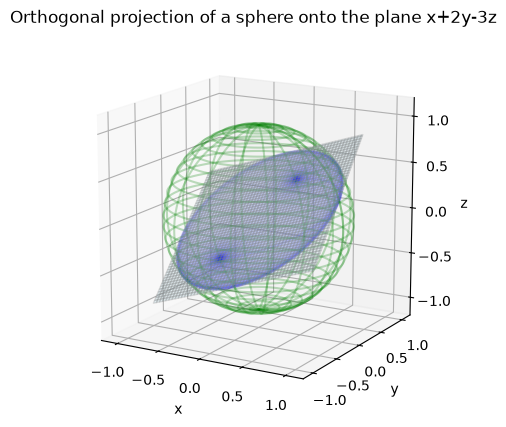

In [15]:
#Let's see how this looks like!
fig = plt.figure(figsize=(8,5))

#drawing axes:
ax = fig.add_subplot(1,1,1, projection="3d")

# Original sphere
#wireframe draws a surface only using lines and not filling up the space
#makes it easier for visualization of the projection
ax.plot_wireframe(
    X_sphere,
    Y_sphere,
    Z_sphere,
    rstride=4,
    cstride=6,
    color="green",
    alpha=0.25
)

# Projected sphere
ax.scatter(
    X_projected.ravel(), #ravel changes any array into a 1 dimensional one, it flattens it
    Y_projected.ravel(),
    Z_projected.ravel(),
    color="blue",
    s=2,
    alpha=0.25
)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=25, azim=-55)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Orthogonal projection of a sphere onto the plane x+2y-3z")

#Generate a mesh: using np.meshgrid:
limit = 1
s = np.linspace(-limit, limit,100)
t = np.linspace(-limit, limit,100)
S,T = np.meshgrid(s, t)
#The span of v_1,v_2 is sv_1 +t v_2!
#In coordinate form:
X = S * w_1[0] + T * w_2[0] 
Y = S * w_1[1] + T * w_2[1] 
Z = S * w_1[2] + T * w_2[2]  

ax.view_init(elev=15, azim=-60)
ax.plot_surface(X, Y, Z, color = 'lightblue', alpha = 0.25, edgecolor = 'gray') #smaller alpha makes surface more transparent


plt.show()